import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    precision_recall_curve, 
    auc
)

Generate the Churn imbalanced Dataset

In [2]:
# Load original dataset
df_orig = pd.read_csv('C:/Users/MSIS/Downloads/APS/lab5/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Separate majority and minority classes
majority = df_orig[df_orig['Churn'] == 'No']
minority = df_orig[df_orig['Churn'] == 'Yes']

# Calculate target minority count for a +5% churn rate (~31.54%)
current_churn_rate = (df_orig['Churn'] == 'Yes').mean()
target_churn_rate = current_churn_rate + 0.05

n_majority = len(majority)
n_minority_target = int(n_majority * target_churn_rate / (1 - target_churn_rate))

# Upsample minority class to hit the target churn rate
minority_upsampled = minority.sample(n=n_minority_target, replace=True, random_state=42)

# Combine, shuffle, and export to new CSV
df_plus_5 = pd.concat([majority, minority_upsampled]).sample(frac=1, random_state=42).reset_index(drop=True)
df_plus_5.to_csv('C:/Users/MSIS/Downloads/APS/lab5/WA_Fn-UseC_-Telco-Customer-Churn_Plus5.csv', index=False)

print(f"Original Churn Rate : {current_churn_rate:.2%}")
print(f"New (+5%) Churn Rate: {(df_plus_5['Churn'] == 'Yes').mean():.2%}")

Original Churn Rate : 26.54%
New (+5%) Churn Rate: 31.53%


load target dataset

In [3]:
df = pd.read_csv('C:/Users/MSIS/Downloads/APS/lab5/WA_Fn-UseC_-Telco-Customer-Churn_Plus5.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5198-HQAEN,Male,0,Yes,Yes,35,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,One year,Yes,Electronic check,89.70,3165.6,No
1,0336-PIKEI,Male,1,Yes,No,72,Yes,No,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Bank transfer (automatic),74.40,5360.75,No
2,7858-GTZSP,Female,0,No,No,12,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.55,1066.9,No
3,0670-KDOMA,Female,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.25,20.25,No
4,9274-UARKJ,Female,0,No,No,15,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),83.20,1130,No


data cleaning

In [4]:
# Convert TotalCharges safely to float and handle missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Drop non-predictive identifier column
df_model = df.drop(columns=['customerID'])

# Map target variable (Churn) to numeric binary format
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

# Separate features (X) and target (y)
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

# One-hot encode categorical variables and handle residual NaNs
X_encoded = pd.get_dummies(X, drop_first=True).astype(float).fillna(0)

print("Encoded Features Shape:", X_encoded.shape)
print("Target Class Distribution:\n", y.value_counts(normalize=True))

Encoded Features Shape: (7557, 30)
Target Class Distribution:
 Churn
0    0.684663
1    0.315337
Name: proportion, dtype: float64


train-test-split

In [5]:
# Perform 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Samples:", X_train_scaled.shape[0])
print("Testing Samples :", X_test_scaled.shape[0])

Training Samples: 6045
Testing Samples : 1512


model train - LR

In [6]:
# Initialize and train model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model training complete.")

Model training complete.


evaluating metrics

In [7]:
# Generate predictions on test set
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Compute PR-AUC score
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recalls, precisions)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}\n")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, zero_division=0))

Precision : 0.6852
Recall    : 0.6205
F1-Score  : 0.6513
ROC-AUC   : 0.8499
PR-AUC    : 0.7201

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.69      0.62      0.65       477

    accuracy                           0.79      1512
   macro avg       0.76      0.74      0.75      1512
weighted avg       0.79      0.79      0.79      1512



plot pr-curve

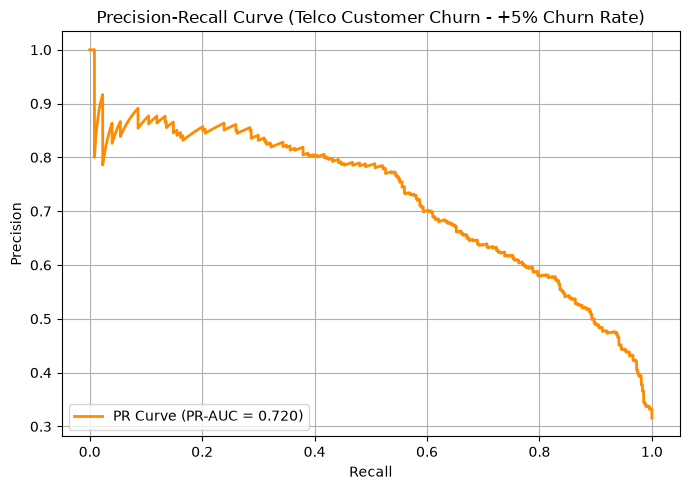

In [8]:
plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, color="darkorange", lw=2, label=f"PR Curve (PR-AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Telco Customer Churn - +5% Churn Rate)")
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.show()